## K-Nearest Neighbors
This file is about using KNN to train a model to predict rating 3.0 of a player.

In [2]:
import pandas as pd
df = pd.read_excel('preprocessed_data.xlsx')
display(df.head())

,Player,Rating 3.0,Kills per round,Kills per round win,Damage per round,Damage per round win,Rounds with a kill,Rounds with a multi-kill,Saved by teammate per round,Traded deaths per round,...,Sniper kills per round,Sniper kills percentage,Rounds with sniper kills percentage,Sniper multi-kill rounds,Sniper opening kills per round,Utility damage per round,Utility kills per 100 rounds,Flashes thrown per round,Flash assists per round,Time opponent flashed per round
0,donk,1.38,4.496020,4.144459,4.251909,3.834787,3.644449,4.552464,0.326134,0.709361,...,-0.482528,-0.487194,-0.477251,-0.422801,-0.436333,-0.847340,-1.479030,-0.870158,-1.603766,-1.789788
1,ZywOo,1.34,3.200176,2.206957,2.583746,1.931851,2.896591,3.308668,-0.370746,-0.815990,...,1.768442,1.334941,1.675290,1.977071,1.850832,-0.301064,0.655636,0.158405,0.503270,0.218072
2,m0NESY,1.26,2.459693,1.948623,1.471637,1.214992,2.373089,2.479470,-1.067627,-0.815990,...,2.411577,2.013997,2.249998,2.608616,2.533568,-1.019848,-0.589586,0.642434,1.346084,0.173453
3,Luken,1.24,2.459693,2.206957,2.257783,1.840615,2.036553,2.427645,0.326134,-0.307540,...,-0.482528,-0.509830,-0.508598,-0.517532,-0.470470,-0.552638,-0.091497,-0.567640,-0.760952,-0.361976
4,Frip,1.23,2.274573,2.723624,3.101452,3.157029,2.036553,2.583120,1.023014,0.709361,...,-0.241353,-0.317430,-0.268266,-0.359646,-0.197375,-0.157307,-0.340541,-0.809654,-0.760952,-0.406595


### 1. Data Preparation and Splitting

First, I'll define the features (`X`) and the target variable (`y`). Then, I'll split the data into training, validation, and test sets using `train_test_split` from `sklearn.model_selection`.

In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Define target variable (y) and features (X)
y = df['Rating 3.0']
X = df.drop(columns=['Player', 'Rating 3.0'])

# Display target variable (y) and features (X)
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
display(X.head())
display(y.head())

Features (X) shape: (453, 37)
Target (y) shape: (453,)


,Kills per round,Kills per round win,Damage per round,Damage per round win,Rounds with a kill,Rounds with a multi-kill,Saved by teammate per round,Traded deaths per round,Opening deaths traded percentage,Assits per round,...,Sniper kills per round,Sniper kills percentage,Rounds with sniper kills percentage,Sniper multi-kill rounds,Sniper opening kills per round,Utility damage per round,Utility kills per 100 rounds,Flashes thrown per round,Flash assists per round,Time opponent flashed per round
0,4.496020,4.144459,4.251909,3.834787,3.644449,4.552464,0.326134,0.709361,-0.220940,0.584043,...,-0.482528,-0.487194,-0.477251,-0.422801,-0.436333,-0.847340,-1.479030,-0.870158,-1.603766,-1.789788
1,3.200176,2.206957,2.583746,1.931851,2.896591,3.308668,-0.370746,-0.815990,-0.498507,-0.346455,...,1.768442,1.334941,1.675290,1.977071,1.850832,-0.301064,0.655636,0.158405,0.503270,0.218072
2,2.459693,1.948623,1.471637,1.214992,2.373089,2.479470,-1.067627,-0.815990,0.241671,-1.587118,...,2.411577,2.013997,2.249998,2.608616,2.533568,-1.019848,-0.589586,0.642434,1.346084,0.173453
3,2.459693,2.206957,2.257783,1.840615,2.036553,2.427645,0.326134,-0.307540,-0.637290,0.894209,...,-0.482528,-0.509830,-0.508598,-0.517532,-0.470470,-0.552638,-0.091497,-0.567640,-0.760952,-0.361976
4,2.274573,2.723624,3.101452,3.157029,2.036553,2.583120,1.023014,0.709361,-0.683551,1.824707,...,-0.241353,-0.317430,-0.268266,-0.359646,-0.197375,-0.157307,-0.340541,-0.809654,-0.760952,-0.406595


,Rating 3.0
0,1.38
1,1.34
2,1.26
3,1.24
4,1.23


In [4]:
# Split data into training (70%), validation (15%), and test (15%) sets

# First split: 85% for train+validation, 15% for test
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# Second split: From the train+validation set, take 15/(100-15) for validation and the rest for training
# This makes the validation set approximately 15% of the total dataset
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=(0.15 / 0.85), random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 317 samples
Validation set size: 68 samples
Test set size: 68 samples


### 2. KNN

Now, let's implement the KNN model.

In [5]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd

# Initialize and train the KNN model
knn_model = KNeighborsRegressor(n_neighbors=3)
knn_model.fit(X_train, y_train)

# --- Predictions and Evaluation for Training Set ---
y_pred_train_knn = knn_model.predict(X_train)
mse_train_knn = mean_squared_error(y_train, y_pred_train_knn)
mae_train_knn = mean_absolute_error(y_train, y_pred_train_knn)
rmse_train_knn = np.sqrt(mse_train_knn)

# --- Predictions and Evaluation for Validation Set ---
y_pred_val_knn = knn_model.predict(X_val)
mse_val_knn = mean_squared_error(y_val, y_pred_val_knn)
mae_val_knn = mean_absolute_error(y_val, y_pred_val_knn)
rmse_val_knn = np.sqrt(mse_val_knn)

# --- Predictions and Evaluation for Test Set ---
y_pred_test_knn = knn_model.predict(X_test)
mse_test_knn = mean_squared_error(y_test, y_pred_test_knn)
mae_test_knn = mean_absolute_error(y_test, y_pred_test_knn)
rmse_test_knn = np.sqrt(mse_test_knn)

print(f"KNN (k=3) - Training Set MSE: {mse_train_knn:.4f}")
print(f"KNN (k=3) - Training Set MAE: {mae_train_knn:.4f}")
print(f"KNN (k=3) - Training Set RMSE: {rmse_train_knn:.4f}")
print(f"KNN (k=3) - Validation Set MSE: {mse_val_knn:.4f}")
print(f"KNN (k=3) - Validation Set MAE: {mae_val_knn:.4f}")
print(f"KNN (k=3) - Validation Set RMSE: {rmse_val_knn:.4f}")
print(f"KNN (k=3) - Test Set MSE: {mse_test_knn:.4f}")
print(f"KNN (k=3) - Test Set MAE: {mae_test_knn:.4f}")
print(f"KNN (k=3) - Test Set RMSE: {rmse_test_knn:.4f}")

# Create a DataFrame for performance metrics
performance_data = {
    'Metric': ['MAE', 'MSE', 'RMSE'],
    'Training Set': [mae_train_knn, mse_train_knn, rmse_train_knn],
    'Validation Set': [mae_val_knn, mse_val_knn, rmse_val_knn],
    'Test Set': [mae_test_knn, mse_test_knn, rmse_test_knn]
}
performance_df_sklearn = pd.DataFrame(performance_data)

display(performance_df_sklearn)

KNN (k=3) - Training Set MSE: 0.0007
KNN (k=3) - Training Set MAE: 0.0202
KNN (k=3) - Training Set RMSE: 0.0262
KNN (k=3) - Validation Set MSE: 0.0020
KNN (k=3) - Validation Set MAE: 0.0365
KNN (k=3) - Validation Set RMSE: 0.0447
KNN (k=3) - Test Set MSE: 0.0022
KNN (k=3) - Test Set MAE: 0.0360
KNN (k=3) - Test Set RMSE: 0.0472


,Metric,Training Set,Validation Set,Test Set
0,MAE,0.020231,0.036520,0.036029
1,MSE,0.000689,0.001998,0.002230
2,RMSE,0.026244,0.044694,0.047222


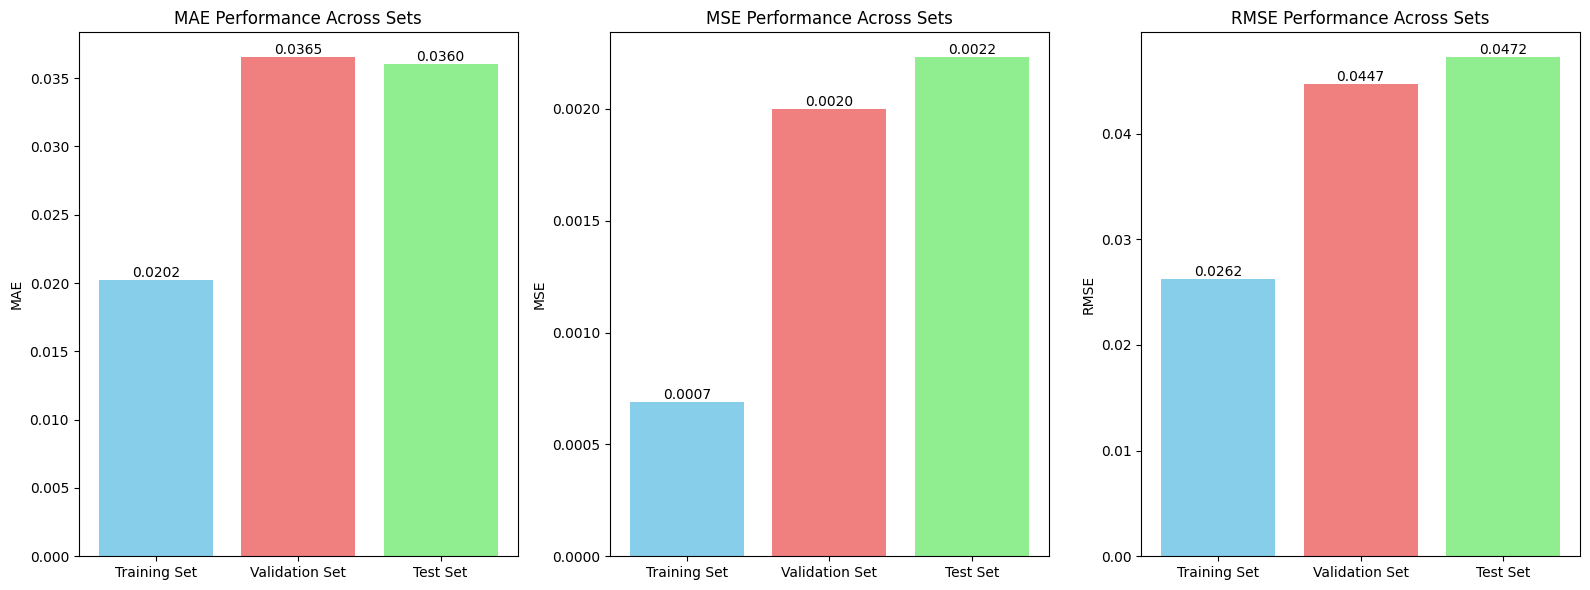

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
axes = axes.flatten()

metrics = ['MAE', 'MSE', 'RMSE']
colors = ['skyblue', 'lightcoral', 'lightgreen']

for i, metric in enumerate(metrics):
    metric_values = performance_df_sklearn[performance_df_sklearn['Metric'] == metric].iloc[0, 1:].values
    sets = ['Training Set', 'Validation Set', 'Test Set']

    axes[i].bar(sets, metric_values, color=colors)
    axes[i].set_title(f'{metric} Performance Across Sets')
    axes[i].set_ylabel(metric)
    for j, val in enumerate(metric_values):
        axes[i].text(j, val, f'{val:.4f}', ha='center', va='bottom')

    axes[i].autoscale(enable=True, axis='y', tight=False)

plt.tight_layout()
plt.show()